## VOC LABELS CHECK

We check the labels are valid in the VOC format (xml)

Image shape: (1962, 4109, 3)
Image height=1962 and width=4109


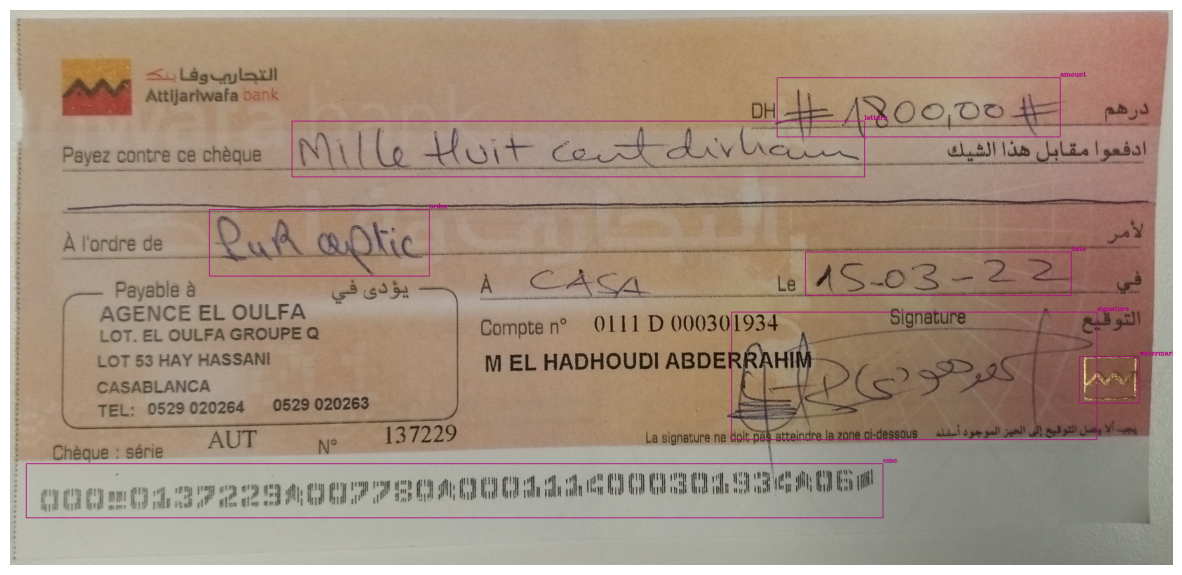

In [6]:
import cv2
import xml.etree.ElementTree as ET

# Reading image with OpenCV library
# In this way image is opened already as numpy array
root = "custom_dataset"

img_path = f'{root}/images/7.jpg'
annotation_path = f'{root}/annotations/7.xml'

image_BGR = cv2.imread(img_path)
image = cv2.cvtColor(image_BGR, cv2.COLOR_BGR2RGB)


# Showing image shape
print('Image shape:', image.shape)  # tuple of (800, 1360, 3)

# Getting spatial dimension of input image
h, w = image.shape[:2]  # Slicing from tuple only first two elements

# Showing height an width of image
print('Image height={0} and width={1}'.format(h, w))  # 800 1360

# Extracting annotation data
tree = ET.parse(annotation_path)
root_obj = tree.getroot()
annotations = []
objs = root_obj.findall('object')
for obj in objs:
    obj_name = obj.find('name').text
    bbox = obj.find('bndbox')
    xmin = int(bbox.find('xmin').text)
    ymin = int(bbox.find('ymin').text)
    xmax = int(bbox.find('xmax').text)
    ymax = int(bbox.find('ymax').text)
    annotations.append((obj_name, xmin, ymin, xmax, ymax))

# Going through all BB
for i in range(len(annotations)):
    # Getting current bounding box coordinates, its width and height
    class_current = annotations[i][0]
    
    # that are x_min and y_min
    x_min = annotations[i][1]
    y_min = annotations[i][2]

    box_width = annotations[i][3] - annotations[i][1]
    box_height = annotations[i][4] - annotations[i][2]

    # Drawing bounding box on the original image
    cv2.rectangle(image, (x_min, y_min), (x_min + box_width, y_min + box_height), [172 , 10, 127], 2)

    # Putting text with label and confidence on the original image
    cv2.putText(image, class_current, (x_min + box_width , y_min - 5), cv2.FONT_HERSHEY_COMPLEX, 0.7, [172 , 10, 127], 2)

import matplotlib.pyplot as plt
%matplotlib inline

# Plotting this example
# Setting default size of the plot
plt.rcParams['figure.figsize'] = (15, 15)

# Initializing the plot
fig = plt.figure()

# plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.imshow(image)
plt.axis('off')

# Showing the plot
plt.show()

## VOC TO YOLO

Converting the annotations to Yolo labels format

In [7]:
import xml.etree.ElementTree as ET
import glob
import os
import json


def xml_to_yolo_bbox(bbox, w, h):
    # xmin, ymin, xmax, ymax
    x_center = ((bbox[2] + bbox[0]) / 2) / w
    y_center = ((bbox[3] + bbox[1]) / 2) / h
    width = (bbox[2] - bbox[0]) / w
    height = (bbox[3] - bbox[1]) / h
    return [x_center, y_center, width, height]


def yolo_to_xml_bbox(bbox, w, h):
    # x_center, y_center width heigth
    w_half_len = (bbox[2] * w) / 2
    h_half_len = (bbox[3] * h) / 2
    xmin = int((bbox[0] * w) - w_half_len)
    ymin = int((bbox[1] * h) - h_half_len)
    xmax = int((bbox[0] * w) + w_half_len)
    ymax = int((bbox[1] * h) + h_half_len)
    return [xmin, ymin, xmax, ymax]


classes = []
# You need to specify the folders here
# The xml annotations folder
input_dir = f"{root}/annotations"
# The yolo labels output folder (where you want to save your yolo labels)
output_dir = f"{root}/labels"
# The images folder
image_dir = f"{root}/images"

# create the labels folder (output directory)
os.mkdir(output_dir)

# identify all the xml files in the annotations folder (input directory)
files = glob.glob(os.path.join(input_dir, '*.xml'))
# loop through each 
for fil in files:
    basename = os.path.basename(fil)
    filename = os.path.splitext(basename)[0]
    # check if the label contains the corresponding image file
    if not os.path.exists(os.path.join(image_dir, f"{filename}.jpg")):
        print(f"{filename} image does not exist!")
        continue

    result = []

    # parse the content of the xml file
    tree = ET.parse(fil)
    root_obj = tree.getroot()
    width = int(root_obj.find("size").find("width").text)
    height = int(root_obj.find("size").find("height").text)

    for obj in root_obj.findall('object'):
        label = obj.find("name").text
        # check for new classes and append to list
        if label not in classes:
            classes.append(label)
        index = classes.index(label)
        pil_bbox = [int(x.text) for x in obj.find("bndbox")]
        yolo_bbox = xml_to_yolo_bbox(pil_bbox, width, height)
        # convert data to string
        bbox_string = " ".join([str(x) for x in yolo_bbox])
        result.append(f"{index} {bbox_string}")

    if result:
        # generate a YOLO format text file for each xml file
        with open(os.path.join(output_dir, f"{filename}.txt"), "w", encoding="utf-8") as f:
            f.write("\n".join(result))

# generate the classes file as reference
with open(f'{root}/classes.txt', 'w', encoding='utf8') as f:
    f.write(json.dumps(classes))

## YOLO LABELS CHECK

Checking if the yolo labels are valid


Image shape: (1962, 4109, 3)
Image height=1962 and width=4109


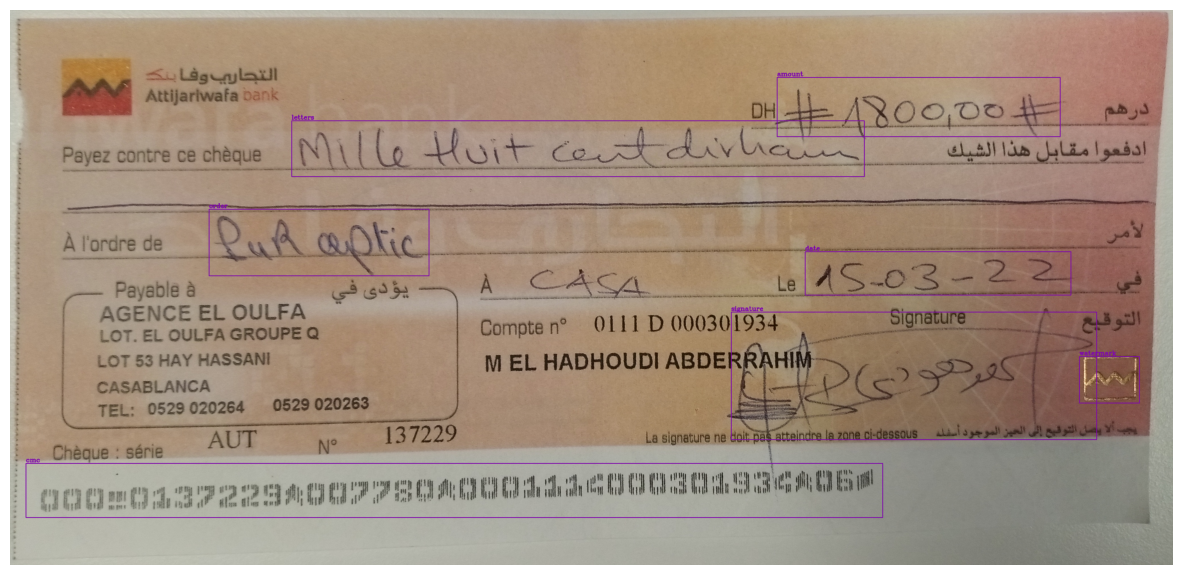

In [8]:
import cv2, ast

# Reading image with OpenCV library
# In this way image is opened already as numpy array
# WARNING! OpenCV by default reads images in BGR format
img_path = f'{root}/images/7.jpg'
image_BGR = cv2.imread(img_path)
aug_label_path = f'{root}/labels/7.txt'
classes_path = f'{root}/classes.txt'

# Showing image shape
print('Image shape:', image_BGR.shape)  # tuple of (800, 1360, 3)

# Getting spatial dimension of input image
h, w = image_BGR.shape[:2]  # Slicing from tuple only first two elements

# Showing height an width of image
print('Image height={0} and width={1}'.format(h, w))  # 800 1360

# Reading annotation txt file that has bounding boxes coordinates in YOLO format
with open(classes_path) as c:
    for line in c:
        classes = line
classes = ast.literal_eval(classes)


with open(aug_label_path) as f:
    # Preparing list for annotation of BB (bounding boxes)
    lst = []
    for line in f:
        lst += [line.rstrip()]

# Going through all BB
for i in range(len(lst)):
    # Getting current bounding box coordinates, its width and height
    bb_current = lst[i].split()
    x_center, y_center = int(float(bb_current[1]) * w), int(float(bb_current[2]) * h)
    box_width, box_height = int(float(bb_current[3]) * w), int(float(bb_current[4]) * h)
    
    # Now, from YOLO data format, we can get top left corner coordinates
    # that are x_min and y_min
    x_min = int(x_center - (box_width / 2))
    y_min = int(y_center - (box_height / 2))

    # Drawing bounding box on the original image
    cv2.rectangle(image_BGR, (x_min, y_min), (x_min + box_width, y_min + box_height), [172 , 10, 127], 2)

    # Preparing text with label and confidence for current bounding box
    class_current = classes[int(bb_current[0])]

    # Putting text with label and confidence on the original image
    cv2.putText(image_BGR, class_current, (x_min, y_min - 5), cv2.FONT_HERSHEY_COMPLEX, 0.7, [172 , 10, 127], 2)

import matplotlib.pyplot as plt
%matplotlib inline

# Plotting this example
# Setting default size of the plot
plt.rcParams['figure.figsize'] = (15, 15)

# Initializing the plot
fig = plt.figure()

plt.imshow(cv2.cvtColor(image_BGR, cv2.COLOR_BGR2RGB))
plt.axis('off')

# Showing the plot
plt.show()

## AUGMENTATION

Augmenting images and labels

In [9]:
import os
import albumentations as A
import cv2

# PATHS
IMAGES_PATH = f'{root}/images'
LABELS_PATH = f'{root}/labels'



# The number of wanted augmentations
nb_aug = 5



def move_first_to_last(lst):
    if len(lst) > 0:
        first_element = lst.pop(0)
        lst.append(first_element)
    return lst

images = sorted(os.listdir(IMAGES_PATH), key=lambda x: x.split('.')[0])
labels = sorted(os.listdir(LABELS_PATH), key=lambda x: x.split('.')[0])
assert len(images) == len(labels), "Number of images and labels should be same"


transform = A.Compose([
    A.OneOf([
        A.RandomBrightness(limit=0.2, p=0.5), 
        A.RandomContrast(limit=0.2, p=0.5)]), # for 0.5 probability, do brightness or contrast
    A.RandomGamma(gamma_limit=(80, 150), p=0.5), # for 0.7 probability, do gamma
    A.CLAHE(), # for 0.5 probability, do CLAHE (Contrast Limited Adaptive Histogram Equalization)
    A.OneOf([
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),
        A.GaussianBlur(blur_limit=3, p=0.5)]),
], bbox_params=A.BboxParams(format='yolo'))


# read image and label and associate them in a dictionary
images_labels = {}

for image_file, label_file in zip(images, labels):
    image = cv2.imread(os.path.join(IMAGES_PATH, image_file))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # read labels and remove firt element in each line (split by space)
    with open(os.path.join(LABELS_PATH, label_file), 'r') as f:
        label_lines = f.readlines()
        label_lines = [line.split(' ') for line in label_lines]
        label_lines = [move_first_to_last(line) for line in label_lines]
        # convert to float
        label_lines = [[float(x) for x in line] for line in label_lines]

        # associate label with image
        images_labels[image_file] = label_lines

augmented_images = []
augmented_labels = []
for i, (image_file, label_lines) in enumerate(images_labels.items()):
    image = cv2.imread(os.path.join(IMAGES_PATH, image_file))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    original_name = image_file
    print(f"Processing image {i + 1}/{len(images)}")

    for i in range(nb_aug):
        image_file = original_name

        # apply augmentation
        transformed = transform(image=image, bboxes=label_lines)
        augmented_images.append(transformed['image'])
        augmented_labels.append(transformed['bboxes'])

        # save augmented image
        image_file = image_file.split('.')[0] + f"_{i}.jpg"
        cv2.imwrite(os.path.join(IMAGES_PATH, image_file), cv2.cvtColor(transformed['image'], cv2.COLOR_RGB2BGR))

        # save augmented labels
        image_file = image_file.replace('.jpg', '.txt')
        label_path = os.path.join(LABELS_PATH, image_file)
        with open(label_path, 'w') as f:
            for bbox in transformed['bboxes']:
                f.write(f"{int(bbox[4])} {bbox[0]} {bbox[1]} {bbox[2]} {bbox[3]}\n")

/home/yazid-tagnaouti/miniconda3/envs/yolo_training/lib/python3.8/site-packages/albumentations/augmentations/transforms.py:1258: FutureWarning: This class has been deprecated. Please use RandomBrightnessContrast
  warnings.warn(
/home/yazid-tagnaouti/miniconda3/envs/yolo_training/lib/python3.8/site-packages/albumentations/augmentations/transforms.py:1284: FutureWarning: RandomContrast has been deprecated. Please use RandomBrightnessContrast
  warnings.warn(
/home/yazid-tagnaouti/miniconda3/envs/yolo_training/lib/python3.8/site-packages/albumentations/augmentations/blur/transforms.py:184: UserWarning: blur_limit and sigma_limit minimum value can not be both equal to 0. blur_limit minimum value changed to 3.
  warnings.warn(


Processing image 1/452
Processing image 2/452
Processing image 3/452
Processing image 4/452
Processing image 5/452
Processing image 6/452
Processing image 7/452
Processing image 8/452
Processing image 9/452
Processing image 10/452
Processing image 11/452
Processing image 12/452
Processing image 13/452
Processing image 14/452
Processing image 15/452
Processing image 16/452
Processing image 17/452
Processing image 18/452
Processing image 19/452
Processing image 20/452
Processing image 21/452
Processing image 22/452
Processing image 23/452
Processing image 24/452
Processing image 25/452
Processing image 26/452
Processing image 27/452
Processing image 28/452
Processing image 29/452
Processing image 30/452
Processing image 31/452
Processing image 32/452
Processing image 33/452
Processing image 34/452
Processing image 35/452
Processing image 36/452
Processing image 37/452
Processing image 38/452
Processing image 39/452
Processing image 40/452
Processing image 41/452
Processing image 42/452
P

## SPLIT TRAIN/DEV

In [9]:
from sklearn.model_selection import train_test_split
import shutil

#Utility function to move images 
def move_files_to_folder(list_of_files, destination_folder):
    for f in list_of_files:
        try:
            shutil.move(f, destination_folder)
        except Exception:
            print(f)
            assert False


# Read images and annotations
image_path = f'{root}/images'
label_path = f'{root}/labels'


images = [os.path.join(image_path, x) for x in os.listdir(image_path)]
annotations = [os.path.join(label_path, x) for x in os.listdir(label_path) if x[-3:] == "txt"]
assert len(images) == len(annotations)

images.sort()
annotations.sort()

# Split the dataset into train-valid-test splits 
train_images, val_images, train_annotations, val_annotations = train_test_split(images, annotations, test_size = 0.2, random_state = 1)
val_images, test_images, val_annotations, test_annotations = train_test_split(val_images, val_annotations, test_size = 0.5, random_state = 1)

folder_names = ['train', 'val', 'test']

for folder_name in folder_names:
    os.mkdir(os.path.join(f'{root}/images', folder_name))
    os.mkdir(os.path.join(f'{root}/labels', folder_name))

# Move the splits into their folders
move_files_to_folder(train_images, f'{root}/images/train')
move_files_to_folder(val_images, f'{root}/images/val/')
move_files_to_folder(test_images, f'{root}/images/test/')
move_files_to_folder(train_annotations, f'{root}/labels/train/')
move_files_to_folder(val_annotations, f'{root}/labels/val/')
move_files_to_folder(test_annotations, f'{root}/labels/test/')